
=== Sampling interval Δt = 0.2 ===
SINDy RMSE: 0.2137   status: ok
SORT  RMSE: 0.21194   status: ok

=== Sampling interval Δt = 0.4 ===
SINDy RMSE: 1.67816   status: ok
SORT  RMSE: 1.12037   status: ok

=== Sampling interval Δt = 0.5 ===
SINDy RMSE: 567.178   status: ok
SORT  RMSE: 1.79268   status: ok

=== Sampling interval Δt = 1.0 ===
SINDy RMSE: 909.127   status: ok
SORT  RMSE: 2.06088   status: ok


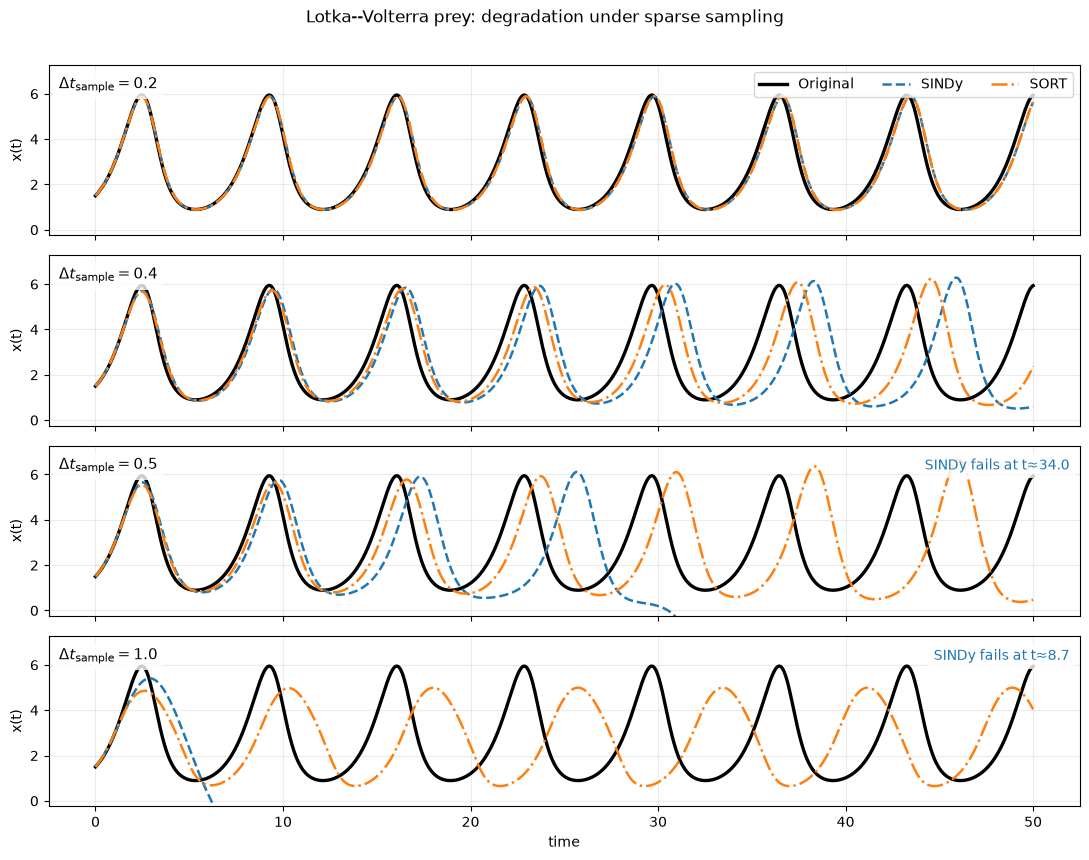

saved: lv_sampling_degradation_prey_stacked


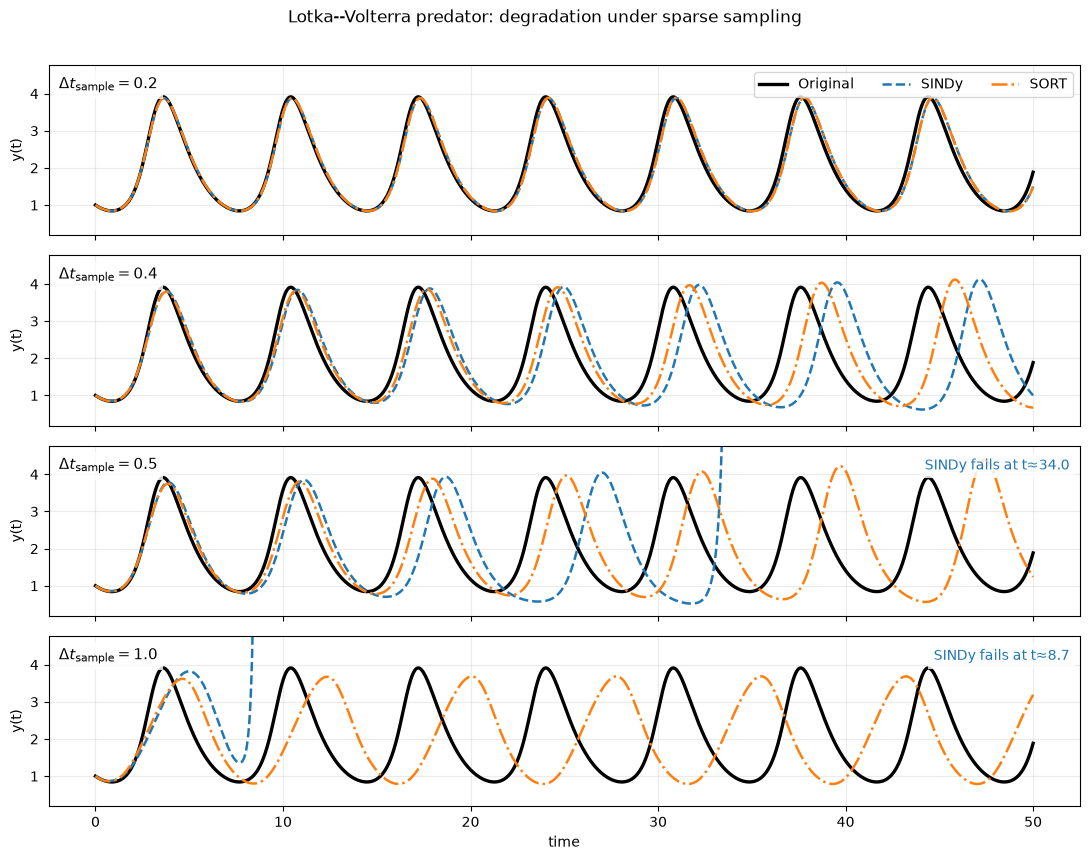

saved: lv_sampling_degradation_predator_stacked


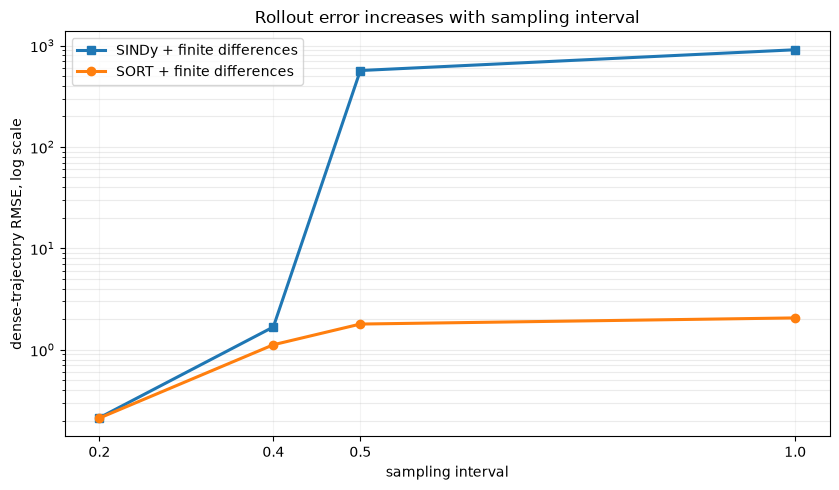

saved: lv_sampling_degradation_rmse_vs_sampling_interval

Summary
-------
      dt |   SINDy RMSE |    SORT RMSE | SINDy fail t |  SORT fail t
----------------------------------------------------------------------
     0.2 |       0.2137 |      0.21194 |         none |         none
     0.4 |       1.6782 |       1.1204 |         none |         none
     0.5 |       567.18 |       1.7927 |        33.97 |         none
     1.0 |       909.13 |       2.0609 |         8.69 |         none

All figures saved in: figs_lv_sampling_degradation


In [13]:
# ============================================================
# Lotka--Volterra sampling-degradation experiment
# ============================================================
#
# This script generates the Lotka--Volterra results used in Figure 1 of:
#   Section 3.1 "Equation discovery from time-series data"
#
# Purpose
# -------
# The experiment compares a SINDy-style sparse identification pipeline with
# the Sparse Orthogonal Regression Technique (SORT) on the classical
# Lotka--Volterra predator-prey system:
#
#       x' = alpha x - beta x y
#       y' = delta x y - gamma y
#
# where x(t) is the prey population and y(t) is the predator population.
#
# The goal is to test robustness under increasingly sparse temporal sampling.
# Since the Lotka--Volterra vector field is polynomial, it is well aligned with
# a standard SINDy polynomial library. Thus, this experiment is not mainly a
# representation-mismatch test; instead, it isolates how each learned model
# degrades when derivative estimates from sparse samples become less reliable.
#
# Experimental pipeline
# ---------------------
# For each sampling interval:
#
# 1. Simulate a clean dense Lotka--Volterra trajectory.
# 2. Subsample the trajectory at the specified sampling interval.
# 3. Estimate derivatives from the sampled states using finite differences.
# 4. Train SINDy and SORT on the same sampled states and derivative estimates.
# 5. Roll out both learned models on the dense evaluation time grid.
# 6. Compare the learned rollouts with the original dense trajectory.
#
# Evaluation
# ----------
# The main metric is dense-trajectory RMSE:
#
#     RMSE = root-mean-square error between the learned rollout and the
#            ground-truth dense Lotka--Volterra trajectory.
#
# RMSE is computed on the dense evaluation grid, not only at the sparse
# training points.
#
# Figure outputs
# --------------
# Paper Figure 1:
#
#   1a. Dense-trajectory RMSE vs sampling interval
#       - linear x-axis: sampling interval
#       - logarithmic y-axis: dense-trajectory RMSE
#       - compares SINDy + finite differences with SORT + finite differences
#
#   1b. Predator trajectory rollouts across sampling intervals
#       - vertically stacked panels for increasing sampling intervals
#       - each panel shows:
#           * original dense predator trajectory
#           * SINDy rollout
#           * SORT rollout
#
# Additional diagnostic outputs, if enabled:
#
#   - prey rollout panels with the same layout as the predator panels
#   - separate RMSE and trajectory-panel figures
#
# Saved to:
#   figs_lv_sampling_degradation/
#
# Connection to the paper
# -----------------------
# This experiment supports the first equation-discovery result in Section 3.1.
# It shows that, as the sampling interval increases, SINDy can become unstable,
# while SORT degrades more gradually and continues to recover bounded
# oscillatory predator dynamics over coarser sampling intervals.
#
# This complements the Thomas and Bessel-driven experiments in Figure 2:
# the Lotka--Volterra study tests sparse temporal sampling in a polynomial
# system favorable to SINDy, while the cyclic-system experiments test noise
# sensitivity and representation mismatch.
#
# Important implementation notes
# ------------------------------
# - Both methods use the same sampled trajectory and finite-difference
#   derivative estimates.
#
# - Both methods are evaluated against the same dense ground-truth trajectory.
#
# - Predator rollouts are emphasized in the paper because they clearly show
#   the transition from accurate recovery to phase error and instability.
#
# - Prey panels, if saved, are auxiliary diagnostics rather than the central
#   manuscript panel.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import warnings

from scipy.integrate import solve_ivp
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# 1. Settings
# ============================================================

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

OUTDIR = "figs_lv_sampling_degradation"
os.makedirs(OUTDIR, exist_ok=True)

SAVE_PDF = True
SAVE_PNG = True
SHOW_FIGS = True

# Plot colors: keep these fixed everywhere
TRUE_COLOR = "black"
SINDY_COLOR = "tab:blue"
SORT_COLOR = "tab:orange"

# Lotka--Volterra parameters
ALPHA = 1.20
BETA  = 0.60
DELTA = 0.30
GAMMA = 0.80

X0 = np.array([1.5, 1.0])

T0, T1 = 0.0, 50.0
DT_DENSE = 0.01

SAMPLE_DTS = [2e-1, 4e-1, 5e-1, 1]
SAMPLE_LABELS = ["0.2", "0.4", "0.5", "1.0"]

NOISE_STD = 0.0

# SINDy
SINDY_POLY_DEGREE = 2
SINDY_THRESHOLD = 0.04
SINDY_RIDGE = 1e-8

# SORT
STATE_LEGENDRE_DEGREE = 5
LASSO_ALPHAS = np.logspace(-7, -2, 80)

# Safety for exploding learned systems
ROLL_OUT_CAP = 1e6
RMSE_CAP = 1e3


# ============================================================
# 2. Utility functions
# ============================================================

def save_fig(fig, filename_base):
    if SAVE_PDF:
        fig.savefig(os.path.join(OUTDIR, f"{filename_base}.pdf"), bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(os.path.join(OUTDIR, f"{filename_base}.png"), dpi=300, bbox_inches="tight")

    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)

    print(f"saved: {filename_base}")


def lotka_volterra_rhs(t, x, alpha=ALPHA, beta=BETA, delta=DELTA, gamma=GAMMA):
    prey, pred = x
    return np.array([
        alpha * prey - beta * prey * pred,
        delta * prey * pred - gamma * pred
    ], dtype=float)


def simulate_true(rhs, x0, t_eval):
    sol = solve_ivp(
        rhs,
        (float(t_eval[0]), float(t_eval[-1])),
        np.asarray(x0, dtype=float),
        t_eval=np.asarray(t_eval, dtype=float),
        rtol=1e-10,
        atol=1e-12,
        max_step=0.02,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y.T


def rk4_rollout_safe(rhs, x0, t_eval, cap=ROLL_OUT_CAP):
    """
    Fixed-step RK4 rollout with failure protection.
    If a learned model explodes, the remaining trajectory is set to NaN.
    """
    t_eval = np.asarray(t_eval, dtype=float)
    X = np.full((len(t_eval), len(x0)), np.nan, dtype=float)
    X[0] = np.asarray(x0, dtype=float)

    for i in range(len(t_eval) - 1):
        t = t_eval[i]
        dt = t_eval[i + 1] - t_eval[i]
        x = X[i]

        if (not np.all(np.isfinite(x))) or np.max(np.abs(x)) > cap:
            break

        try:
            k1 = rhs(t, x)
            k2 = rhs(t + 0.5 * dt, x + 0.5 * dt * k1)
            k3 = rhs(t + 0.5 * dt, x + 0.5 * dt * k2)
            k4 = rhs(t + dt, x + dt * k3)
            x_next = x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
        except Exception:
            break

        if (not np.all(np.isfinite(x_next))) or np.max(np.abs(x_next)) > cap:
            break

        X[i + 1] = x_next

    return X


def finite_difference_derivative(t, X):
    """
    Finite-difference derivative on the sampled trajectory.
    """
    t = np.asarray(t, dtype=float)
    X = np.asarray(X, dtype=float)

    if len(t) < 3:
        return np.gradient(X, t, axis=0, edge_order=1)

    return np.gradient(X, t, axis=0, edge_order=2)


def capped_rmse(Xhat, Xtrue, cap=RMSE_CAP):
    """
    RMSE with a finite penalty for exploding or missing trajectories.
    This prevents failed SINDy rollouts from producing NaN/infinite plots.
    """
    Xhat = np.asarray(Xhat, dtype=float)
    Xtrue = np.asarray(Xtrue, dtype=float)

    err = Xhat - Xtrue
    bad = ~np.isfinite(err)
    err[bad] = cap
    err = np.clip(err, -cap, cap)

    return float(np.sqrt(np.mean(err**2)))


def failure_time(Xhat, t_eval):
    Xhat = np.asarray(Xhat)
    good = np.all(np.isfinite(Xhat), axis=1)
    if np.all(good):
        return np.nan
    idx = np.argmax(~good)
    return float(t_eval[idx])


# ============================================================
# 3. SINDy-style polynomial model
# ============================================================

def monomial_powers(n_vars, degree):
    powers = []

    def rec(prefix, remaining_degree, dim_left):
        if dim_left == 1:
            powers.append(tuple(prefix + [remaining_degree]))
            return
        for k in range(remaining_degree + 1):
            rec(prefix + [k], remaining_degree - k, dim_left - 1)

    for total_degree in range(degree + 1):
        rec([], total_degree, n_vars)

    return powers


def build_poly_library(X, degree=SINDY_POLY_DEGREE):
    X = np.asarray(X, dtype=float)
    n_samples, n_vars = X.shape
    powers = monomial_powers(n_vars, degree)

    Theta = np.ones((n_samples, len(powers)), dtype=float)

    for col, p in enumerate(powers):
        val = np.ones(n_samples, dtype=float)
        for j, exponent in enumerate(p):
            if exponent:
                val *= X[:, j] ** exponent
        Theta[:, col] = val

    return Theta, powers


def eval_poly_features(x, powers):
    x = np.asarray(x, dtype=float)
    phi = np.ones(len(powers), dtype=float)

    for col, p in enumerate(powers):
        val = 1.0
        for j, exponent in enumerate(p):
            if exponent:
                val *= x[j] ** exponent
        phi[col] = val

    return phi


def ridge_solve(A, B, alpha=SINDY_RIDGE):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    return np.linalg.solve(A.T @ A + alpha * np.eye(A.shape[1]), A.T @ B)


def stlsq(Theta, dXdt, threshold=SINDY_THRESHOLD, ridge_alpha=SINDY_RIDGE, max_iter=10):
    Theta = np.asarray(Theta, dtype=float)
    dXdt = np.asarray(dXdt, dtype=float)

    col_norms = np.linalg.norm(Theta, axis=0)
    col_norms[col_norms == 0] = 1.0
    Theta_n = Theta / col_norms

    Xi = ridge_solve(Theta_n, dXdt, ridge_alpha)

    for _ in range(max_iter):
        small = np.abs(Xi) < threshold
        Xi[small] = 0.0

        for j in range(dXdt.shape[1]):
            active = ~small[:, j]
            if np.sum(active) == 0:
                continue
            Xi[active, j] = ridge_solve(
                Theta_n[:, active],
                dXdt[:, j:j+1],
                ridge_alpha
            ).ravel()

    return Xi / col_norms[:, None]


def fit_sindy_fd(X, dXdt, degree=SINDY_POLY_DEGREE):
    Theta, powers = build_poly_library(X, degree=degree)
    Xi = stlsq(Theta, dXdt)

    def rhs(t, x):
        return eval_poly_features(x, powers) @ Xi

    return {
        "rhs": rhs,
        "Xi": Xi,
        "powers": powers,
    }


# ============================================================
# 4. SORT-style Legendre vector-field model
# ============================================================

class MinMaxScalerMinusOneOne:
    def __init__(self, padding=0.05, eps=1e-12):
        self.padding = padding
        self.eps = eps
        self.xmin = None
        self.xmax = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        xmin = X.min(axis=0)
        xmax = X.max(axis=0)
        span = np.maximum(xmax - xmin, self.eps)
        self.xmin = xmin - self.padding * span
        self.xmax = xmax + self.padding * span
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        span = np.maximum(self.xmax - self.xmin, self.eps)
        return 2.0 * (X - self.xmin) / span - 1.0


def normalized_legendre_vander(z, degree):
    z = np.asarray(z, dtype=float)
    V = np.polynomial.legendre.legvander(z, degree)
    norms = np.sqrt((2.0 * np.arange(degree + 1) + 1.0) / 2.0)
    return V * norms[None, :]


def total_degree_indices(n_vars, degree):
    indices = []

    def rec(prefix, remaining_degree, dim_left):
        if dim_left == 1:
            indices.append(tuple(prefix + [remaining_degree]))
            return
        for k in range(remaining_degree + 1):
            rec(prefix + [k], remaining_degree - k, dim_left - 1)

    for total_degree in range(degree + 1):
        rec([], total_degree, n_vars)

    return indices


def build_legendre_state_library(Z, degree=STATE_LEGENDRE_DEGREE):
    Z = np.asarray(Z, dtype=float)
    Z = np.clip(Z, -1.0, 1.0)

    n_samples, n_vars = Z.shape
    indices = total_degree_indices(n_vars, degree)

    one_dim = [normalized_legendre_vander(Z[:, j], degree) for j in range(n_vars)]

    Phi = np.ones((n_samples, len(indices)), dtype=float)
    for col, alpha in enumerate(indices):
        val = np.ones(n_samples, dtype=float)
        for j, deg_j in enumerate(alpha):
            val *= one_dim[j][:, deg_j]
        Phi[:, col] = val

    return Phi, indices


def eval_legendre_state_features(z, indices, degree=STATE_LEGENDRE_DEGREE):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -1.0, 1.0)

    one_dim = [
        normalized_legendre_vander(np.array([zj]), degree)[0]
        for zj in z
    ]

    phi = np.ones(len(indices), dtype=float)
    for col, alpha in enumerate(indices):
        val = 1.0
        for j, deg_j in enumerate(alpha):
            val *= one_dim[j][deg_j]
        phi[col] = val

    return phi


def fit_sort_fd(X, dXdt, degree=STATE_LEGENDRE_DEGREE, alphas=LASSO_ALPHAS):
    scaler = MinMaxScalerMinusOneOne(padding=0.05).fit(X)
    Z = scaler.transform(X)

    Phi, indices = build_legendre_state_library(Z, degree=degree)

    models = []
    for j in range(dXdt.shape[1]):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            model = LassoCV(
                alphas=alphas,
                fit_intercept=True,
                cv=min(5, len(X)),
                max_iter=100000,
                tol=1e-8,
                random_state=RANDOM_SEED,
            )
            model.fit(Phi, dXdt[:, j])
        models.append(model)

    def rhs(t, x):
        z = scaler.transform(np.asarray(x, dtype=float)[None, :])[0]
        phi = eval_legendre_state_features(z, indices, degree=degree)
        return np.array([m.predict(phi[None, :])[0] for m in models])

    return {
        "rhs": rhs,
        "models": models,
        "scaler": scaler,
        "indices": indices,
    }


# ============================================================
# 5. Run sampling sweep
# ============================================================

t_dense = np.arange(T0, T1 + 1e-12, DT_DENSE)
X_true = simulate_true(lotka_volterra_rhs, X0, t_dense)

results = []

for dt_obs, label in zip(SAMPLE_DTS, SAMPLE_LABELS):
    print(f"\n=== Sampling interval Δt = {label} ===")

    t_obs = np.arange(T0, T1 + 0.5 * dt_obs, dt_obs)

    X_obs_clean = np.column_stack([
        np.interp(t_obs, t_dense, X_true[:, j])
        for j in range(X_true.shape[1])
    ])

    X_obs = X_obs_clean + rng.normal(0.0, NOISE_STD, size=X_obs_clean.shape)

    dX_fd = finite_difference_derivative(t_obs, X_obs)

    # Fit SINDy
    try:
        sindy = fit_sindy_fd(X_obs, dX_fd)
        X_sindy = rk4_rollout_safe(sindy["rhs"], X_obs_clean[0], t_dense)
        sindy_status = "ok"
    except Exception as e:
        print("SINDy failed during fitting:", repr(e))
        sindy = None
        X_sindy = np.full_like(X_true, np.nan)
        sindy_status = "fit failed"

    # Fit SORT
    try:
        sort = fit_sort_fd(X_obs, dX_fd)
        X_sort = rk4_rollout_safe(sort["rhs"], X_obs_clean[0], t_dense)
        sort_status = "ok"
    except Exception as e:
        print("SORT failed during fitting:", repr(e))
        sort = None
        X_sort = np.full_like(X_true, np.nan)
        sort_status = "fit failed"

    err_sindy = capped_rmse(X_sindy, X_true)
    err_sort = capped_rmse(X_sort, X_true)

    print(f"SINDy RMSE: {err_sindy:.6g}   status: {sindy_status}")
    print(f"SORT  RMSE: {err_sort:.6g}   status: {sort_status}")

    results.append({
        "dt": dt_obs,
        "label": label,
        "t_obs": t_obs,
        "X_obs": X_obs,
        "dX_fd": dX_fd,
        "sindy": sindy,
        "sort": sort,
        "X_sindy": X_sindy,
        "X_sort": X_sort,
        "rmse_sindy": err_sindy,
        "rmse_sort": err_sort,
        "fail_time_sindy": failure_time(X_sindy, t_dense),
        "fail_time_sort": failure_time(X_sort, t_dense),
    })


# ============================================================
# 6. Plot vertically stacked rollout panels
# ============================================================

def finite_for_plot(Y):
    Y = np.asarray(Y, dtype=float).copy()
    Y[~np.isfinite(Y)] = np.nan
    return Y


def component_ylim_from_true_and_sort(component, margin=0.10):
    vals = [X_true[:, component]]

    for r in results:
        ys = r["X_sort"][:, component]
        ys = ys[np.isfinite(ys)]
        ys = ys[np.abs(ys) < ROLL_OUT_CAP]
        if len(ys):
            vals.append(ys)

    vals = np.concatenate(vals)
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    span = max(hi - lo, 1e-8)

    return lo - margin * span, hi + margin * span


def plot_stacked_component(component, filename_base):
    comp_name = "prey" if component == 0 else "predator"
    y_label = "x(t)" if component == 0 else "y(t)"
    ylim = component_ylim_from_true_and_sort(component)

    n = len(results)
    fig, axes = plt.subplots(
        n,
        1,
        figsize=(11, 2.15 * n),
        sharex=True,
    )

    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        ax.plot(
            t_dense,
            X_true[:, component],
            color=TRUE_COLOR,
            linewidth=2.4,
            label="Original",
        )

        ax.plot(
            t_dense,
            finite_for_plot(r["X_sindy"][:, component]),
            color=SINDY_COLOR,
            linewidth=1.8,
            linestyle="--",
            label="SINDy",
        )

        ax.plot(
            t_dense,
            finite_for_plot(r["X_sort"][:, component]),
            color=SORT_COLOR,
            linewidth=1.8,
            linestyle="-.",
            label="SORT",
        )

        ax.set_ylim(*ylim)
        ax.grid(alpha=0.25)
        ax.set_ylabel(y_label)

        ax.text(
            0.01,
            0.86,
            rf"$\Delta t_\mathrm{{sample}}={r['label']}$",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
        )

        if np.isfinite(r["fail_time_sindy"]):
            ax.text(
                0.99,
                0.86,
                f"SINDy fails at t≈{r['fail_time_sindy']:.1f}",
                transform=ax.transAxes,
                ha="right",
                fontsize=10,
                color=SINDY_COLOR,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
            )

    axes[0].legend(loc="upper right", ncol=3)
    axes[-1].set_xlabel("time")

    fig.suptitle(
        f"Lotka--Volterra {comp_name}: degradation under sparse sampling",
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.985])

    save_fig(fig, filename_base)


plot_stacked_component(
    component=0,
    filename_base="lv_sampling_degradation_prey_stacked",
)

plot_stacked_component(
    component=1,
    filename_base="lv_sampling_degradation_predator_stacked",
)


# ============================================================
# 7. Plot RMSE vs sampling interval
# Log-linear: linear x-axis, log y-axis
# ============================================================

dt_vals = np.array([r["dt"] for r in results], dtype=float)
rmse_sindy = np.array([r["rmse_sindy"] for r in results], dtype=float)
rmse_sort = np.array([r["rmse_sort"] for r in results], dtype=float)

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    dt_vals,
    rmse_sindy,
    color=SINDY_COLOR,
    marker="s",
    linewidth=2.2,
    label="SINDy + finite differences",
)

ax.plot(
    dt_vals,
    rmse_sort,
    color=SORT_COLOR,
    marker="o",
    linewidth=2.2,
    label="SORT + finite differences",
)

# Linear x-axis, log y-axis
ax.set_yscale("log")

ax.set_xlabel("sampling interval")
ax.set_ylabel("dense-trajectory RMSE, log scale")
ax.set_title("Rollout error increases with sampling interval")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.grid(True, axis="x", which="major", alpha=0.15)

ax.set_xticks(dt_vals)
ax.set_xticklabels([r["label"] for r in results])

ax.legend(loc="best")

fig.tight_layout()
save_fig(fig, "lv_sampling_degradation_rmse_vs_sampling_interval")


# ============================================================
# 8. Print compact summary table
# ============================================================

print("\nSummary")
print("-------")
print(f"{'dt':>8s} | {'SINDy RMSE':>12s} | {'SORT RMSE':>12s} | {'SINDy fail t':>12s} | {'SORT fail t':>12s}")
print("-" * 70)

for r in results:
    ft_sindy = "none" if not np.isfinite(r["fail_time_sindy"]) else f"{r['fail_time_sindy']:.2f}"
    ft_sort = "none" if not np.isfinite(r["fail_time_sort"]) else f"{r['fail_time_sort']:.2f}"

    print(
        f"{r['label']:>8s} | "
        f"{r['rmse_sindy']:12.5g} | "
        f"{r['rmse_sort']:12.5g} | "
        f"{ft_sindy:>12s} | "
        f"{ft_sort:>12s}"
    )

print(f"\nAll figures saved in: {OUTDIR}")